# EGFR Virtual Biopsy — Figure Generation Notebook

Builds on `EGFR_Multimodal_Training_v3_2.ipynb` — Sections 1–12 below (data loading,
preprocessing, radiomics, model, train/predict) are copied **verbatim** from that notebook, so this
reuses your existing `egfr_cache/` and `egfr_out/radiomics_*.csv` caches if they're present in the
working directory (no need to reprocess DICOM from scratch).

**What this notebook adds, starting at Section 13:**
- Modified cross-validation runners that **capture and save** per-patient out-of-fold (OOF)
  predicted probabilities and per-fold AUROC/AUPRC arrays — the raw data the original notebook
  computes internally but discards after printing the summary line.
- Four publication-ready figures built from that raw data:
  1. **Fold-wise AUROC distribution** (box plot) across all 7 ablation models — a more rigorous
     complement to the mean±SD bar chart already in the paper.
  2. **ROC curves** for the three headline models (clinical-only, image-only, FULL).
  3. **Calibration curve** (reliability diagram) for clinical-only vs. FULL.
  4. **Confusion matrix** at the optimal (Youden's J) threshold for the FULL model.
- Everything is saved to `figures_out/` (PNGs) and `figures_out/raw_data/` (JSON/CSV), so you can
  send the raw data back for different figure styling without re-running the whole pipeline.

**Run this in the same working directory as `EGFR_Multimodal_Training_v3_2.ipynb`** — same `data/`
folder, same place you'd normally launch that notebook from (wherever your `egfr_cache/` and
`egfr_out/` directories actually live — check with `find / -iname egfr_out 2>/dev/null` if unsure).


## 1. Install (run once)

In [1]:
import sys
# !{sys.executable} -m pip install -q "pydicom<3" pydicom-seg SimpleITK scipy scikit-learn scikit-image matplotlib tqdm torchvision
print("done")
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

done


## 2. Imports

In [2]:
import os, glob, shutil, random, warnings, math, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import pydicom, pydicom_seg, SimpleITK as sitk
from scipy import ndimage
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x
warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch", torch.__version__, "| Device:", DEVICE)
from sklearn.calibration import calibration_curve
import json
import pandas as pd


Torch 2.12.1+cu126 | Device: cpu


d:\git\PhDProjects\LungCancerGrading\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. CONFIG

In [3]:
DATA_ROOT    = Path("data/nsclc_radiogenomics")
CLINICAL_CSV = Path("data/NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv")
AIM_DIR      = Path("data/AIM_files_updated-11-10-2020/AIM_files_updated-11-10-2020")
CACHE_BASE   = Path("egfr_cache")
OUTPUT_DIR   = Path("egfr_out"); OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_COL, POS_LABEL, NEG_LABEL = "EGFR mutation status", "Mutant", "Wildtype"

TARGET_SHAPE   = (32, 64, 64); CROP_PAD_VOX = 16
HU_MIN, HU_MAX = -1000, 400
REQUIRE_SEG    = False
USE_AIM_COORD_FALLBACK = True
ALLOW_CENTER_CROP_FALLBACK = False
AIM_DEPTH_SLICES = TARGET_SHAPE[0]
FORCE_REBUILD  = False

INCLUDE_HISTOLOGY = False
INCLUDE_ETHNICITY = True

IMAGE_BACKBONE = "2.5d"            # keep 2.5d (best/most stable image branch)
PRETRAINED     = True
IMG_FEAT_DIM   = 64; TAB_HIDDEN = 64; FUSION_HIDDEN = 64; DROPOUT = 0.4
FREEZE_SLICE_BACKBONE=True; VIT_D_MODEL=192; VIT_HEADS=3; VIT_LAYERS=2; VIT_FF=384; SLICE_RES=224

N_FOLDS = 5; N_REPEATS = 5; EPOCHS = 60; LR = 1e-4; WEIGHT_DECAY = 1e-4
BATCH_SIZE = 8; USE_AUGMENTATION = True; USE_CLASS_WEIGHTS = True; SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PRE_TAG = f"seg{int(REQUIRE_SEG)}_aim{int(USE_AIM_COORD_FALLBACK)}_{TARGET_SHAPE[0]}x{TARGET_SHAPE[1]}x{TARGET_SHAPE[2]}_pad{CROP_PAD_VOX}"
CACHE_DIR = CACHE_BASE / PRE_TAG
if FORCE_REBUILD and CACHE_DIR.exists(): shutil.rmtree(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("cache:", CACHE_DIR)

FIG_DIR = Path("figures_out"); FIG_DIR.mkdir(exist_ok=True)
RAW_DIR = FIG_DIR / "raw_data"; RAW_DIR.mkdir(exist_ok=True)
print("Figures will be saved to:", FIG_DIR.resolve())
print("Raw exported data will be saved to:", RAW_DIR.resolve())


cache: egfr_cache\seg0_aim1_32x64x64_pad16
Figures will be saved to: D:\git\PhDProjects\LungCancerGrading\figures_out
Raw exported data will be saved to: D:\git\PhDProjects\LungCancerGrading\figures_out\raw_data


## 4. Clinical labels + tabular features

In [4]:
clin = pd.read_csv(CLINICAL_CSV)
clin["Case ID"] = clin["Case ID"].astype(str).str.strip()
clin["label"] = clin[TARGET_COL].map({POS_LABEL: 1, NEG_LABEL: 0})
clin = clin.dropna(subset=["label"]).copy(); clin["label"] = clin["label"].astype(int)
print("Usable EGFR labels:", len(clin)); print(clin["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

def build_tabular(df):
    f = pd.DataFrame(index=df.index)
    age = pd.to_numeric(df["Age at Histological Diagnosis"], errors="coerce")
    f["age"] = age.fillna(age.median())/100.0
    f["male"] = (df["Gender"].astype(str).str.strip().str.lower()=="male").astype(float)
    sm = df["Smoking status"].astype(str).str.strip()
    for v in ["Nonsmoker","Former","Current"]: f[f"smk_{v}"] = (sm==v).astype(float)
    for c in [c for c in df.columns if c.startswith("Tumor Location")]:
        key = c.split("choice=")[-1].rstrip(")").strip().replace(" ","_")
        f[f"loc_{key}"] = (df[c].astype(str).str.strip().str.lower()=="checked").astype(float)
    f = pd.concat([f, pd.get_dummies(df["%GG"].astype(str).str.strip(), prefix="gg").astype(float)], axis=1)
    if INCLUDE_ETHNICITY and "Ethnicity" in df.columns:
        f = pd.concat([f, pd.get_dummies(df["Ethnicity"].astype(str).str.strip(), prefix="eth").astype(float)], axis=1)
    if INCLUDE_HISTOLOGY:
        f = pd.concat([f, pd.get_dummies(df["Histology "].astype(str).str.strip(), prefix="hist").astype(float)], axis=1)
    return f
print("Tabular features:", build_tabular(clin).shape[1])

Usable EGFR labels: 172
label
Wildtype    129
Mutant       43
Name: count, dtype: int64
Tabular features: 25


## 5. Index DICOM + match AIM files

In [5]:
ALL_AIM = glob.glob(os.path.join(str(AIM_DIR), "*.xml")) if AIM_DIR.exists() else []
def aim_file_for(cid):
    mf = [f for f in ALL_AIM if cid in os.path.basename(f)]
    return mf[0] if mf else None

def scan_patient(pdir):
    info = {"ct_dir": None, "ct_n": 0, "seg_file": None, "seg_modality": None}
    for root, _, files in os.walk(pdir):
        dcms = [f for f in files if f.lower().endswith(".dcm")]
        if not dcms: continue
        try: ds = pydicom.dcmread(os.path.join(root, dcms[0]), stop_before_pixels=True, force=True)
        except Exception: continue
        mod = str(getattr(ds, "Modality", "")).upper()
        if mod == "CT":
            if len(dcms) > info["ct_n"]: info["ct_dir"], info["ct_n"] = root, len(dcms)
        elif mod in ("SEG","RTSTRUCT"):
            info["seg_file"], info["seg_modality"] = os.path.join(root, dcms[0]), mod
    return info

records = []
for cid in tqdm(clin["Case ID"].tolist(), desc="indexing"):
    pdir = DATA_ROOT/cid
    info = scan_patient(pdir) if pdir.exists() else {"ct_dir":None,"ct_n":0,"seg_file":None,"seg_modality":None}
    info["Case ID"] = cid; info["aim_file"] = aim_file_for(cid); records.append(info)
cohort = clin.merge(pd.DataFrame(records), on="Case ID", how="left")
print("CT:", cohort["ct_dir"].notna().sum(), "| SEG:", (cohort["seg_modality"]=="SEG").sum(),
      "| AIM:", cohort["aim_file"].notna().sum())

indexing: 100%|██████████| 172/172 [00:25<00:00,  6.81it/s]

CT: 172 | SEG: 117 | AIM: 158


## 6. AIM markup parser + coordinate cropper

In [6]:
def _local(t): return t.rsplit('}',1)[-1]
def parse_aim_markup(xml_path):
    out=[]
    try: root=ET.parse(xml_path).getroot()
    except Exception: return out
    for me in root.iter():
        if _local(me.tag)!="MarkupEntity": continue
        sop=None;frame=None;pts=[]
        for el in me.iter():
            lt=_local(el.tag)
            if lt=="imageReferenceUid": sop=el.get("root")
            elif lt=="referencedFrameNumber": frame=el.get("value")
            elif lt=="TwoDimensionSpatialCoordinate":
                x=y=None
                for c in el:
                    if _local(c.tag)=="x": x=float(c.get("value"))
                    if _local(c.tag)=="y": y=float(c.get("value"))
                if x is not None and y is not None: pts.append((x,y))
        if pts: out.append({"sop":sop,"frame":frame,"xy":pts})
    return out

def sop_to_zindex(ct_dir):
    files=sitk.ImageSeriesReader().GetGDCMSeriesFileNames(str(ct_dir)); m={}
    for i,fp in enumerate(files):
        try:
            ds=pydicom.dcmread(fp,stop_before_pixels=True,force=True); m[str(getattr(ds,'SOPInstanceUID',''))]=i
        except Exception: pass
    return m

def _finish_cube(crop):
    if crop.size==0 or min(crop.shape)<2: return None
    crop=ndimage.zoom(crop.astype(np.float32),[t/max(1,s) for t,s in zip(TARGET_SHAPE,crop.shape)],order=1)
    crop=np.clip(crop,HU_MIN,HU_MAX)
    return ((crop-HU_MIN)/(HU_MAX-HU_MIN)).astype(np.float32)

def crop_from_aim(ct_arr, sop_map, markups):
    Z,Y,X=ct_arr.shape
    for mk in markups:
        if mk["sop"] not in sop_map: continue
        z=sop_map[mk["sop"]]; pts=mk["xy"]; cx,cy=pts[0]
        r=math.hypot(pts[1][0]-cx,pts[1][1]-cy) if len(pts)>=2 else 25.0
        r=max(r,10.0); half=int(round(r))+CROP_PAD_VOX; dz=AIM_DEPTH_SLICES//2
        y0,y1=max(0,int(cy)-half),min(Y,int(cy)+half); x0,x1=max(0,int(cx)-half),min(X,int(cx)+half)
        z0,z1=max(0,z-dz),min(Z,z+dz)
        cube=_finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])
        if cube is not None: return cube,"ok"
    return None,"no_resolvable_markup"

## 7. Preprocess -> tumour cubes (SEG first, AIM fallback)

In [7]:
def load_ct(ct_dir):
    r=sitk.ImageSeriesReader(); r.SetFileNames(r.GetGDCMSeriesFileNames(str(ct_dir))); return r.Execute()
def seg_mask_on_ct(seg_file, ct_img):
    result=pydicom_seg.SegmentReader().read(pydicom.dcmread(seg_file)); mask=None
    for num in result.available_segments:
        res=sitk.Resample(result.segment_image(num),ct_img,sitk.Transform(),sitk.sitkNearestNeighbor,0,sitk.sitkUInt8)
        a=sitk.GetArrayFromImage(res).astype(bool); mask=a if mask is None else (mask|a)
    return mask
def crop_to_cube(ct_arr, mask):
    if mask is not None and mask.any():
        zz,yy,xx=np.where(mask); p=CROP_PAD_VOX
        z0,z1=max(0,zz.min()-p),min(ct_arr.shape[0],zz.max()+p+1)
        y0,y1=max(0,yy.min()-p),min(ct_arr.shape[1],yy.max()+p+1)
        x0,x1=max(0,xx.min()-p),min(ct_arr.shape[2],xx.max()+p+1)
    else:
        Z,Y,X=ct_arr.shape; z0,z1=int(Z*.25),int(Z*.75);y0,y1=int(Y*.2),int(Y*.8);x0,x1=int(X*.2),int(X*.8)
    return _finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])

status=[]
for _,row in tqdm(cohort.iterrows(), total=len(cohort), desc="preprocess"):
    cid=row["Case ID"]; out=CACHE_DIR/f"{cid}.npy"
    if out.exists(): status.append((cid,"cached")); continue
    if pd.isna(row["ct_dir"]): status.append((cid,"no_ct")); continue
    try:
        ct=load_ct(row["ct_dir"]); ct_arr=sitk.GetArrayFromImage(ct); mask=None
        if row["seg_modality"]=="SEG":
            try: mask=seg_mask_on_ct(row["seg_file"],ct)
            except Exception: mask=None
        if mask is not None and mask.any():
            cube=crop_to_cube(ct_arr,mask)
            if cube is not None: np.save(out,cube); status.append((cid,"ok_seg")); continue
        if USE_AIM_COORD_FALLBACK and isinstance(row["aim_file"],str):
            markups=parse_aim_markup(row["aim_file"])
            if markups:
                cube,_=crop_from_aim(ct_arr,sop_to_zindex(row["ct_dir"]),markups)
                if cube is not None: np.save(out,cube); status.append((cid,"ok_aim")); continue
                status.append((cid,"aim_unresolved")); continue
            status.append((cid,"aim_no_markup")); continue
        if ALLOW_CENTER_CROP_FALLBACK and not REQUIRE_SEG:
            cube=crop_to_cube(ct_arr,None)
            if cube is not None: np.save(out,cube); status.append((cid,"ok_centercrop")); continue
        status.append((cid,"no_seg_skipped"))
    except Exception as e: status.append((cid,f"error:{type(e).__name__}"))

st=pd.DataFrame(status,columns=["Case ID","status"]); print(st["status"].value_counts())
cohort=cohort.merge(st,on="Case ID",how="left")
cohort=cohort[cohort["status"].isin(["ok_seg","ok_aim","ok_centercrop","cached"])].reset_index(drop=True)
print("\nFinal cohort:",len(cohort)); print(cohort["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

preprocess: 100%|██████████| 172/172 [02:41<00:00,  1.06it/s]

status
cached            139
aim_unresolved     20
no_seg_skipped     13
Name: count, dtype: int64

Final cohort: 139
label
Wildtype    106
Mutant       33
Name: count, dtype: int64


## 8. Radiomics features (first-order + shape + GLCM)

In [8]:
def tumor_roi(cube, thr=0.5):
    m=cube>thr; D,H,W=cube.shape
    if not m.any():
        m=np.zeros_like(cube,bool); m[D//4:3*D//4,H//4:3*H//4,W//4:3*W//4]=True; return m
    lbl,n=ndimage.label(m); cl=lbl[D//2,H//2,W//2]
    if cl>0: return lbl==cl
    sizes=ndimage.sum(np.ones_like(lbl),lbl,index=range(1,n+1))
    return lbl==(1+int(np.argmax(sizes)))

def radiomics_features(cube):
    f={}; roi=tumor_roi(cube); vals=cube[roi]
    if vals.size<8: vals=cube.ravel()
    f["fo_mean"]=vals.mean(); f["fo_std"]=vals.std(); f["fo_median"]=np.median(vals)
    f["fo_p10"]=np.percentile(vals,10); f["fo_p90"]=np.percentile(vals,90)
    f["fo_iqr"]=np.percentile(vals,75)-np.percentile(vals,25)
    f["fo_min"]=vals.min(); f["fo_max"]=vals.max(); f["fo_range"]=vals.max()-vals.min()
    f["fo_mad"]=np.mean(np.abs(vals-vals.mean())); f["fo_skew"]=skew(vals); f["fo_kurt"]=kurtosis(vals)
    f["fo_energy"]=np.mean(vals**2)
    cnt,_=np.histogram(vals,bins=32,range=(0,1)); p=cnt/max(1,cnt.sum()); pp=p[p>0]
    f["fo_entropy"]=-(pp*np.log2(pp)).sum(); f["fo_uniformity"]=(p**2).sum()
    vol=float(roi.sum()); f["sh_volume"]=vol; coords=np.argwhere(roi)
    if len(coords)>0:
        bb=coords.max(0)-coords.min(0)+1
        f["sh_extent"]=vol/float(np.prod(bb)); f["sh_elongation"]=float(bb.min()/max(1,bb.max()))
    else: f["sh_extent"]=0.0; f["sh_elongation"]=0.0
    er=ndimage.binary_erosion(roi); surf=float((roi&~er).sum())
    f["sh_surface"]=surf; f["sh_sa_vol"]=surf/max(1.0,vol)
    f["sh_sphericity"]=float((4*np.pi*((3*vol/(4*np.pi))**(2/3)))/max(1.0,surf)) if vol>0 else 0.0
    areas=roi.sum((1,2)); z=int(np.argmax(areas)) if areas.max()>0 else cube.shape[0]//2
    sl=cube[z]
    if roi[z].any():
        ys,xs=np.where(roi[z]); sl=sl[ys.min():ys.max()+1, xs.min():xs.max()+1]
    levels=16; q=np.clip((sl*(levels-1)).round(),0,levels-1).astype(np.uint8)
    props=["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]
    if min(q.shape)>=3:
        glcm=graycomatrix(q,distances=[1],angles=[0,np.pi/4,np.pi/2,3*np.pi/4],levels=levels,symmetric=True,normed=True)
        for pr in props: f[f"tex_{pr}"]=float(np.nan_to_num(graycoprops(glcm,pr).mean()))
    else:
        for pr in props: f[f"tex_{pr}"]=0.0
    return f

RAD_CACHE=OUTPUT_DIR/f"radiomics_{PRE_TAG}.csv"
if RAD_CACHE.exists():
    rad_df=pd.read_csv(RAD_CACHE).set_index("Case ID")
else:
    rows={}
    for cid in tqdm(cohort["Case ID"], desc="radiomics"):
        rows[cid]=radiomics_features(np.load(CACHE_DIR/f"{cid}.npy"))
    rad_df=pd.DataFrame.from_dict(rows,orient="index"); rad_df.index.name="Case ID"
    rad_df.reset_index().to_csv(RAD_CACHE,index=False)
rad_df=rad_df.reindex(cohort["Case ID"]).fillna(0.0)
rad_mat_raw=np.nan_to_num(rad_df.values.astype(np.float32))
N_RAD=rad_mat_raw.shape[1]
RAD_MAT=np.nan_to_num(StandardScaler().fit_transform(rad_mat_raw)).astype(np.float32)
print("Radiomics features:",N_RAD); print(list(rad_df.columns))

Radiomics features: 27
['fo_mean', 'fo_std', 'fo_median', 'fo_p10', 'fo_p90', 'fo_iqr', 'fo_min', 'fo_max', 'fo_range', 'fo_mad', 'fo_skew', 'fo_kurt', 'fo_energy', 'fo_entropy', 'fo_uniformity', 'sh_volume', 'sh_extent', 'sh_elongation', 'sh_surface', 'sh_sa_vol', 'sh_sphericity', 'tex_contrast', 'tex_dissimilarity', 'tex_homogeneity', 'tex_energy', 'tex_correlation', 'tex_ASM']


## 9. Tabular matrix + Dataset

In [9]:
tab_mat=build_tabular(cohort).values.astype(np.float32)
N_TAB=tab_mat.shape[1]; labels=cohort["label"].values.astype(np.float32)
print("Tabular dim:",N_TAB,"| Radiomics dim:",N_RAD,"| N:",len(cohort),"| positives:",int(labels.sum()))

def augment_cube(cube):
    if random.random()<0.5: cube=torch.flip(cube,dims=[2])
    if random.random()<0.5: cube=torch.flip(cube,dims=[3])
    cube=cube*random.uniform(0.9,1.1)+random.uniform(-0.05,0.05)
    return cube.clamp(0,1)

class EGFRDataset(Dataset):
    def __init__(self, indices, train=False):
        self.indices=list(indices); self.train=train
    def __len__(self): return len(self.indices)
    def __getitem__(self,k):
        i=self.indices[k]
        cube=np.load(CACHE_DIR/f"{cohort.iloc[i]['Case ID']}.npy")
        img=torch.from_numpy(cube).float().unsqueeze(0)
        if self.train and USE_AUGMENTATION: img=augment_cube(img)
        tab=torch.from_numpy(tab_mat[i]).float()
        rad=torch.from_numpy(RAD_MAT[i]).float()
        y=torch.tensor([labels[i]],dtype=torch.float32)
        return img,tab,rad,y

Tabular dim: 25 | Radiomics dim: 27 | N: 139 | positives: 33


## 10. Model — image (2.5D) + clinical MLP + radiomics MLP -> fusion

In [10]:
class Image25DEncoder(nn.Module):
    def __init__(self,out_dim=IMG_FEAT_DIM,pretrained=PRETRAINED,p=DROPOUT):
        super().__init__()
        net=tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT if pretrained else None)
        self.features=nn.Sequential(*list(net.children())[:-1])
        self.proj=nn.Sequential(nn.Flatten(),nn.Dropout(p),nn.Linear(512,out_dim),nn.ReLU(inplace=True))
        self.register_buffer("mean",torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def forward(self,cube):
        D=cube.shape[2]; idx=[D//4,D//2,(3*D)//4]
        x=cube[:,0][:,idx,:,:]; x=F.interpolate(x,size=(224,224),mode="bilinear",align_corners=False)
        x=(x-self.mean)/self.std; return self.proj(self.features(x))

class Image3DEncoder(nn.Module):
    def __init__(self,out_dim=IMG_FEAT_DIM,p=DROPOUT):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv3d(ci,co,3,padding=1),nn.BatchNorm3d(co),nn.ReLU(inplace=True),nn.MaxPool3d(2))
        self.net=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),nn.AdaptiveAvgPool3d(1),nn.Flatten())
        self.proj=nn.Sequential(nn.Dropout(p),nn.Linear(64,out_dim),nn.ReLU(inplace=True))
    def forward(self,x): return self.proj(self.net(x))

def make_image_encoder():
    if IMAGE_BACKBONE=="3d": return Image3DEncoder()
    return Image25DEncoder()

class MLPEncoder(nn.Module):
    def __init__(self,n_in,hidden=TAB_HIDDEN,out_dim=32,p=DROPOUT):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(n_in,hidden),nn.ReLU(inplace=True),nn.Dropout(p),
                               nn.Linear(hidden,out_dim),nn.ReLU(inplace=True))
    def forward(self,x): return self.net(x)

class FusionNet(nn.Module):
    def __init__(self,n_tab,n_rad,use_image=True,use_tabular=True,use_radiomics=False):
        super().__init__()
        self.use_image,self.use_tabular,self.use_radiomics=use_image,use_tabular,use_radiomics; dim=0
        if use_image: self.img=make_image_encoder(); dim+=IMG_FEAT_DIM
        if use_tabular: self.tab=MLPEncoder(n_tab); dim+=32
        if use_radiomics: self.rad=MLPEncoder(n_rad); dim+=32
        self.head=nn.Sequential(nn.Linear(dim,FUSION_HIDDEN),nn.ReLU(inplace=True),
                                nn.Dropout(DROPOUT),nn.Linear(FUSION_HIDDEN,1))
    def forward(self,img,tab,rad):
        f=[]
        if self.use_image: f.append(self.img(img))
        if self.use_tabular: f.append(self.tab(tab))
        if self.use_radiomics: f.append(self.rad(rad))
        return self.head(torch.cat(f,1))

_m=FusionNet(N_TAB,N_RAD,True,True,True)
print("FULL model trainable params:",sum(p.numel() for p in _m.parameters() if p.requires_grad)); del _m

FULL model trainable params: 11225281


## 11. Train + predict

In [11]:
from torch.cuda.amp import autocast, GradScaler

@torch.no_grad()
def predict(model, loader):
    model.eval(); P,Y=[],[]
    for img,tab,rad,y in loader:
        img,tab,rad=img.to(DEVICE),tab.to(DEVICE),rad.to(DEVICE)
        with autocast(enabled=(DEVICE=="cuda")): logit=model(img,tab,rad)
        P.append(torch.sigmoid(logit).float().cpu().numpy().ravel()); Y.append(y.numpy().ravel())
    return np.concatenate(P), np.concatenate(Y)

def train_one(train_idx,val_idx,use_image=True,use_tabular=True,use_radiomics=False):
    tr=DataLoader(EGFRDataset(train_idx,train=True),batch_size=BATCH_SIZE,shuffle=True)
    va=DataLoader(EGFRDataset(val_idx,train=False),batch_size=BATCH_SIZE,shuffle=False)
    model=FusionNet(N_TAB,N_RAD,use_image,use_tabular,use_radiomics).to(DEVICE)
    params=[p for p in model.parameters() if p.requires_grad]
    opt=torch.optim.AdamW(params,lr=LR,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS)
    scaler=GradScaler(enabled=(DEVICE=="cuda")); pw=None
    if USE_CLASS_WEIGHTS:
        n_pos=labels[train_idx].sum(); pw=torch.tensor([(len(train_idx)-n_pos)/max(1.0,n_pos)],device=DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pw); best_auc,best_state=-1.0,None
    for ep in range(EPOCHS):
        model.train()
        for img,tab,rad,y in tr:
            img,tab,rad,y=img.to(DEVICE),tab.to(DEVICE),rad.to(DEVICE),y.to(DEVICE)
            opt.zero_grad()
            with autocast(enabled=(DEVICE=="cuda")): loss=crit(model(img,tab,rad),y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        p,yt=predict(model,va); auc=roc_auc_score(yt,p) if len(np.unique(yt))>1 else 0.5
        if auc>best_auc: best_auc=auc; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state); return model

## 12. Repeated CV — modified to capture OOF predictions and fold-level arrays

Same logic as the original notebook's Section 13, with two changes: `logreg_repeated` now also
returns the averaged out-of-fold probability per patient (previously discarded), and every call
site below keeps that return value instead of discarding it with `_`.


In [12]:
def stratifier():
    return (cohort["label"].astype(str)+"_"+cohort["Patient affiliation"].astype(str)).values

def run_cv(use_image,use_tabular,use_radiomics,tag,seed):
    global RAD_MAT
    skf=StratifiedKFold(n_splits=N_FOLDS,shuffle=True,random_state=seed)
    oof=np.zeros(len(cohort)); fa=[];fp=[]
    for f,(tr,va) in enumerate(skf.split(np.arange(len(cohort)),stratifier())):
        if use_radiomics:
            sc=StandardScaler().fit(rad_mat_raw[tr]); RAD_MAT=np.nan_to_num(sc.transform(rad_mat_raw)).astype(np.float32)
        m=train_one(tr,va,use_image,use_tabular,use_radiomics)
        p,yt=predict(m,DataLoader(EGFRDataset(va),batch_size=BATCH_SIZE)); oof[va]=p
        if len(np.unique(yt))>1: fa.append(roc_auc_score(yt,p)); fp.append(average_precision_score(yt,p))
    return oof,fa,fp

def run_cv_repeated(use_image,use_tabular,use_radiomics,tag,n_repeats=N_REPEATS):
    """Same as the original - already returns oof_sum/n_repeats, this notebook just keeps it."""
    A=[];P=[];oof_sum=np.zeros(len(cohort))
    for r in range(n_repeats):
        oof,fa,fp=run_cv(use_image,use_tabular,use_radiomics,tag,seed=SEED+r); A+=fa;P+=fp;oof_sum+=oof
        print(f"  [{tag}] seed {SEED+r}: fold-AUROC {np.mean(fa):.3f}")
    print(f"[{tag}] AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} | AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}"
          f" | pooled-OOF {roc_auc_score(labels.astype(int),oof_sum/n_repeats):.3f}\n")
    return oof_sum/n_repeats,A,P

def logreg_repeated(X,name,n_repeats=N_REPEATS):
    """Modified: now also returns the averaged OOF probability per patient (oof_mean),
    in addition to the per-fold AUROC/AUPRC lists the original function returned."""
    A=[];P=[]; oof_sum=np.zeros(len(cohort))
    for r in range(n_repeats):
        oof=np.zeros(len(cohort))
        skf=StratifiedKFold(n_splits=N_FOLDS,shuffle=True,random_state=SEED+r)
        for tr,va in skf.split(np.arange(len(cohort)),stratifier()):
            lr=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced"))
            lr.fit(X[tr],labels[tr].astype(int)); p=lr.predict_proba(X[va])[:,1]; yt=labels[va].astype(int)
            oof[va]=p
            if len(np.unique(yt))>1: A.append(roc_auc_score(yt,p)); P.append(average_precision_score(yt,p))
        oof_sum += oof
    oof_mean = oof_sum / n_repeats
    print(f"[{name}] AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} | AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}"
          f" | pooled-OOF {roc_auc_score(labels.astype(int),oof_mean):.3f}")
    return A,P,oof_mean


## 13. Run all 7 ablation models, capturing fold arrays + OOF predictions

Same seven models as the paper's Table 2, run identically — the only change is that OOF
predictions and fold-level arrays are kept this time instead of discarded.


In [13]:
print(">>> Instant logreg ablations")
A_clin,P_clin,OOF_clin = logreg_repeated(tab_mat, "clinical-only (logreg)")
A_rad, P_rad, OOF_rad  = logreg_repeated(rad_mat_raw, "radiomics-only (logreg)")
A_cr,  P_cr,  OOF_cr   = logreg_repeated(np.hstack([tab_mat,rad_mat_raw]), "clinical+radiomics (logreg)")

print("\n>>> Deep ablations (repeated CV)")
OOF_cd,A_cd,P_cd     = run_cv_repeated(False,True,False,"clinical-only (deep)")
OOF_img,A_img,P_img   = run_cv_repeated(True,False,False,"image-only (deep)")
OOF_fus,A_fus,P_fus   = run_cv_repeated(True,True,False,"image+clinical (fusion)")
OOF_full,A_full,P_full = run_cv_repeated(True,True,True,"image+clinical+radiomics (FULL)")

fold_results = {
    "clinical-only (logreg)":       {"auroc": A_clin, "auprc": P_clin},
    "radiomics-only (logreg)":      {"auroc": A_rad,  "auprc": P_rad},
    "clinical+radiomics (logreg)":  {"auroc": A_cr,   "auprc": P_cr},
    "clinical-only (deep)":         {"auroc": A_cd,   "auprc": P_cd},
    "image-only (deep)":            {"auroc": A_img,  "auprc": P_img},
    "image+clinical (fusion)":      {"auroc": A_fus,  "auprc": P_fus},
    "image+clinical+radiomics (FULL)": {"auroc": A_full, "auprc": P_full},
}
with open(RAW_DIR / "fold_results.json", "w") as f:
    json.dump(fold_results, f, indent=2)
print("Saved per-fold AUROC/AUPRC arrays ->", RAW_DIR / "fold_results.json")

oof_df = pd.DataFrame({
    "Case ID": cohort["Case ID"].values,
    "site": cohort["Patient affiliation"].values,
    "label": labels.astype(int),
    "clinical_logreg": OOF_clin,
    "radiomics_logreg": OOF_rad,
    "clinical_radiomics_logreg": OOF_cr,
    "clinical_deep": OOF_cd,
    "image_deep": OOF_img,
    "image_clinical_fusion": OOF_fus,
    "full_deep": OOF_full,
})
oof_df.to_csv(RAW_DIR / "oof_predictions.csv", index=False)
print("Saved per-patient OOF predictions ->", RAW_DIR / "oof_predictions.csv")


>>> Instant logreg ablations
[clinical-only (logreg)] AUROC 0.726 +/- 0.109 | AUPRC 0.519 +/- 0.156 | pooled-OOF 0.718
[radiomics-only (logreg)] AUROC 0.624 +/- 0.135 | AUPRC 0.438 +/- 0.121 | pooled-OOF 0.619
[clinical+radiomics (logreg)] AUROC 0.698 +/- 0.104 | AUPRC 0.498 +/- 0.146 | pooled-OOF 0.708

>>> Deep ablations (repeated CV)
  [clinical-only (deep)] seed 0: fold-AUROC 0.792
  [clinical-only (deep)] seed 1: fold-AUROC 0.731
  [clinical-only (deep)] seed 2: fold-AUROC 0.776
  [clinical-only (deep)] seed 3: fold-AUROC 0.727
  [clinical-only (deep)] seed 4: fold-AUROC 0.758
[clinical-only (deep)] AUROC 0.757 +/- 0.101 | AUPRC 0.568 +/- 0.142 | pooled-OOF 0.707

  [image-only (deep)] seed 0: fold-AUROC 0.710
  [image-only (deep)] seed 1: fold-AUROC 0.739
  [image-only (deep)] seed 2: fold-AUROC 0.699
  [image-only (deep)] seed 3: fold-AUROC 0.683
  [image-only (deep)] seed 4: fold-AUROC 0.771
[image-only (deep)] AUROC 0.721 +/- 0.085 | AUPRC 0.520 +/- 0.109 | pooled-OOF 0.723

 

## 14. Figure A — Fold-wise AUROC distribution (box plot)

A more rigorous complement to the mean±SD bar chart already in the paper: this shows the full
spread of all 25 fold-level AUROC values per model, not just their mean and SD.


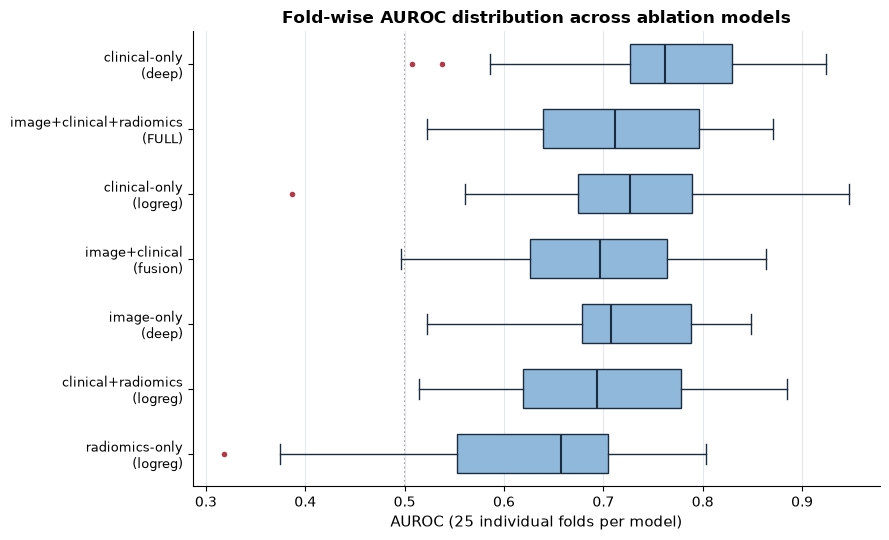

Saved -> figures_out\figA_fold_distribution_boxplot.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

order = ["radiomics-only (logreg)", "clinical+radiomics (logreg)", "image-only (deep)",
         "image+clinical (fusion)", "clinical-only (logreg)", "image+clinical+radiomics (FULL)",
         "clinical-only (deep)"]
data = [fold_results[k]["auroc"] for k in order]
labels_short = [k.replace(" (", "\n(") for k in order]

fig, ax = plt.subplots(figsize=(9, 5.5))
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6,
                 medianprops=dict(color="#1B2C40", linewidth=1.5),
                 boxprops=dict(facecolor="#8FB8DA", edgecolor="#1B2C40"),
                 whiskerprops=dict(color="#1B2C40"), capprops=dict(color="#1B2C40"),
                 flierprops=dict(marker="o", markersize=4, markerfacecolor="#B23A48", markeredgecolor="none"))
ax.set_yticklabels(labels_short, fontsize=9)
ax.axvline(0.5, color="#888888", linestyle=":", linewidth=1.2, zorder=0)
ax.set_xlabel("AUROC (25 individual folds per model)", fontsize=10.5)
ax.set_title("Fold-wise AUROC distribution across ablation models", fontsize=12, weight="bold")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(axis="x", color="#E5E9ED", zorder=-1)
plt.tight_layout()
plt.savefig(FIG_DIR / "figA_fold_distribution_boxplot.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved ->", FIG_DIR / "figA_fold_distribution_boxplot.png")


## 15. Figure B — ROC curves

ROC curves computed on the averaged out-of-fold predictions (same "pooled-OOF" probabilities the
original notebook already prints as a secondary check) for the three headline models. Note in the
paper text that this is for visualization; the primary reported metric remains fold-wise mean±SD.


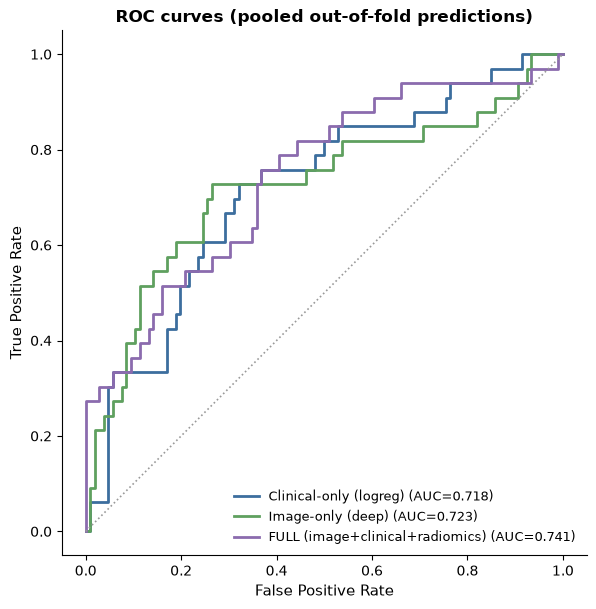

Saved -> figures_out\figB_roc_curves.png


In [15]:
from sklearn.metrics import roc_curve, auc as sk_auc

fig, ax = plt.subplots(figsize=(6.2, 6.2))
roc_models = [
    ("Clinical-only (logreg)", OOF_clin, "#3C6E9E"),
    ("Image-only (deep)",      OOF_img,  "#5FA05F"),
    ("FULL (image+clinical+radiomics)", OOF_full, "#8B6BAE"),
]
for name, oof, color in roc_models:
    fpr, tpr, _ = roc_curve(labels.astype(int), oof)
    roc_auc = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], color="#999999", linestyle=":", linewidth=1.2)
ax.set_xlabel("False Positive Rate", fontsize=10.5)
ax.set_ylabel("True Positive Rate", fontsize=10.5)
ax.set_title("ROC curves (pooled out-of-fold predictions)", fontsize=12, weight="bold")
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "figB_roc_curves.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved ->", FIG_DIR / "figB_roc_curves.png")


## 16. Figure C — Calibration curve (reliability diagram)

Shows whether each model's predicted probabilities are trustworthy as probabilities (e.g., among
patients predicted 70% likely mutant, are close to 70% actually mutant?), not just whether they
rank patients correctly (which is all AUROC measures). This is a standard, often-expected figure
for a clinical prediction-model paper that AUROC alone does not cover.


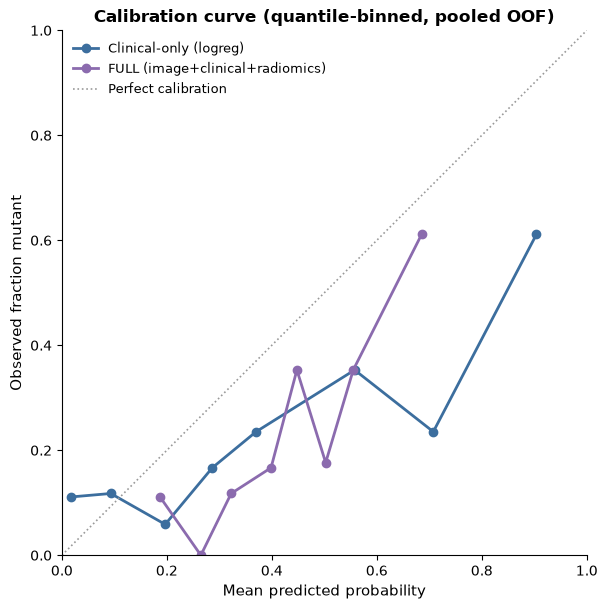

Saved -> figures_out\figC_calibration_curve.png


In [16]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
cal_models = [
    ("Clinical-only (logreg)", OOF_clin, "#3C6E9E"),
    ("FULL (image+clinical+radiomics)", OOF_full, "#8B6BAE"),
]
for name, oof, color in cal_models:
    frac_pos, mean_pred = calibration_curve(labels.astype(int), oof, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2, markersize=6, label=name)

ax.plot([0, 1], [0, 1], color="#999999", linestyle=":", linewidth=1.2, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability", fontsize=10.5)
ax.set_ylabel("Observed fraction mutant", fontsize=10.5)
ax.set_title("Calibration curve (quantile-binned, pooled OOF)", fontsize=12, weight="bold")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "figC_calibration_curve.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved ->", FIG_DIR / "figC_calibration_curve.png")


## 17. Figure D — Confusion matrix at optimal threshold (FULL model)

Threshold chosen by Youden's J statistic (maximizing sensitivity + specificity − 1) on the pooled
OOF predictions, matching the `evaluate()` function already used in the original notebook's
Section 14.


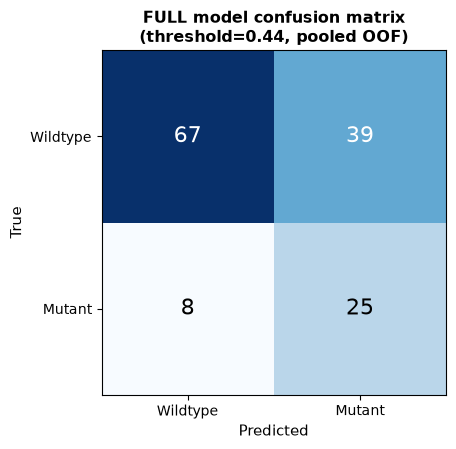

Threshold: 0.443
Sensitivity (recall): 0.758
Specificity: 0.632
PPV: 0.391  |  NPV: 0.893
Saved -> figures_out\figD_confusion_matrix.png


In [17]:
from sklearn.metrics import confusion_matrix, roc_curve as _roc_curve

y = labels.astype(int)
fpr, tpr, thr = _roc_curve(y, OOF_full)
best_t = thr[np.argmax(tpr - fpr)]
pred = (OOF_full >= best_t).astype(int)
cm = confusion_matrix(y, pred)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=16, color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Wildtype", "Mutant"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Wildtype", "Mutant"], fontsize=10)
ax.set_xlabel("Predicted", fontsize=10.5); ax.set_ylabel("True", fontsize=10.5)
ax.set_title(f"FULL model confusion matrix\n(threshold={best_t:.2f}, pooled OOF)", fontsize=11.5, weight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "figD_confusion_matrix.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Threshold: {best_t:.3f}")
print(f"Sensitivity (recall): {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")
print(f"PPV: {tp/max(1,tp+fp):.3f}  |  NPV: {tn/max(1,tn+fn):.3f}")
print("Saved ->", FIG_DIR / "figD_confusion_matrix.png")


## 18. Summary

All figures are saved to `figures_out/` and the raw data behind them to `figures_out/raw_data/`.
Send back the whole `figures_out/` folder (or at minimum `raw_data/fold_results.json` and
`raw_data/oof_predictions.csv`, which are small text files) to get these figures styled and slotted
into the paper, or restyled without re-running the notebook.


In [18]:
import os
print("Files in figures_out/:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(" ", f.name)
print("\nFiles in figures_out/raw_data/:")
for f in sorted(RAW_DIR.glob("*")):
    print(" ", f.name)


Files in figures_out/:
  figA_fold_distribution_boxplot.png
  figB_roc_curves.png
  figC_calibration_curve.png
  figD_confusion_matrix.png

Files in figures_out/raw_data/:
  fold_results.json
  oof_predictions.csv
